In [1]:
!pip install xgboost joblib -q 2>&1 | tail -3


In [2]:
import os, sys, time, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_fscore_support, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml

warnings.filterwarnings("ignore")
os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Shared risk scoring (identical to image notebook)
W = {"accuracy_drop": 0.35, "confidence_drop": 0.25,
     "attack_success_rate": 0.25, "worst_class_asr": 0.15}
THRESHOLD = 0.5

def compute_risk_score(accuracy_drop, confidence_drop, asr, worst_class_asr):
    score = (W["accuracy_drop"] * min(accuracy_drop, 1)
           + W["confidence_drop"] * min(max(confidence_drop, 0), 1)
           + W["attack_success_rate"] * asr
           + W["worst_class_asr"] * worst_class_asr)
    gate = "BLOCK" if score > THRESHOLD else "PASS"
    return score, gate


Device: cpu


## 1 — Data Preparation

UCI Adult Income: binary classification (>50K vs <=50K).
One-hot encode categoricals, standard-scale numericals, 70/15/15 stratified split.


In [3]:
adult = fetch_openml("adult", version=2, as_frame=True, parser="auto")
df = adult.frame
print(f"Raw dataset: {df.shape}")

# Clean missing values
df = df.replace("?", np.nan).dropna()
print(f"After dropping missing: {df.shape}")

# Identify target
target_col = [c for c in df.columns if "income" in c.lower() or "class" in c.lower()][-1]
print(f"Target column: {target_col}")
print("Target distribution:")
print(df[target_col].value_counts())

y_raw = (df[target_col].astype(str).str.contains(">50K")).astype(int).values
X_raw = df.drop(columns=[target_col])

cat_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_raw.select_dtypes(include=["number"]).columns.tolist()
print(f"Categorical: {len(cat_cols)} | Numerical: {len(num_cols)}")

X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True).astype(float)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded.values, y_raw, test_size=0.15, random_state=SEED, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_min = X_train.min(axis=0)
X_train_max = X_train.max(axis=0)

N_FEATURES = X_train.shape[1]
print(f"Train={X_train.shape[0]} | Val={X_val.shape[0]} | Test={X_test.shape[0]}")
print(f"Features: {N_FEATURES} | Positive rate: {y_train.mean():.2%}")


Raw dataset: (48842, 15)
After dropping missing: (45222, 15)
Target column: class
Target distribution:
class
<=50K    34014
>50K     11208
Name: count, dtype: int64
Categorical: 8 | Numerical: 6
Train=31672 | Val=6766 | Test=6784
Features: 97 | Positive rate: 24.79%


## 2 — Model Definitions


In [4]:
import xgboost as xgb

tab_lr = LogisticRegression(max_iter=1000, random_state=SEED)

tab_xgb = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    eval_metric="logloss", use_label_encoder=False, random_state=SEED, verbosity=0)

class TabularNN(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, num_classes))
    def forward(self, x):
        return self.net(x)

tab_nn = TabularNN(N_FEATURES).to(device)
tab_model_meta = {
    "LogReg": {"params": "after_fit", "flops": "N/A"},
    "XGBoost": {"params": "100 trees", "flops": "N/A"},
    "TabularNN": {"params": sum(p.numel() for p in tab_nn.parameters()), "flops": "N/A"}
}
print(f"TabularNN params: {tab_model_meta['TabularNN']['params']:,}")


TabularNN params: 23,394


## 3 — Training All Three Models


In [5]:
tab_histories = {}

# --- Logistic Regression ---
print("=" * 60)
print("Training: LogReg")
print("=" * 60)
t0 = time.time()
tab_lr.fit(X_train, y_train)
lr_t = time.time() - t0
lr_va = accuracy_score(y_val, tab_lr.predict(X_val))
lr_p = tab_lr.coef_.size + tab_lr.intercept_.size
tab_model_meta["LogReg"]["params"] = lr_p
joblib.dump(tab_lr, "outputs/models/tab_logreg.pkl")
lr_ck = os.path.getsize("outputs/models/tab_logreg.pkl") / 1024**2
tab_histories["LogReg"] = {
    "total_time": lr_t, "peak_vram_mb": 0, "ckpt_size_mb": lr_ck,
    "best_val_acc": lr_va, "train_loss": [], "val_loss": [],
    "val_acc": [lr_va], "epoch_time": [lr_t], "has_curves": False}
print(f"  Done -- {lr_t:.1f}s | Val Acc: {100*lr_va:.2f}% | Params: {lr_p:,}")

# --- XGBoost ---
print()
print("=" * 60)
print("Training: XGBoost")
print("=" * 60)
t0 = time.time()
tab_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_t = time.time() - t0
xgb_va = accuracy_score(y_val, tab_xgb.predict(X_val))
xgb_trees = sum(1 for _ in tab_xgb.get_booster().get_dump())
tab_model_meta["XGBoost"]["params"] = f"{xgb_trees} trees"
joblib.dump(tab_xgb, "outputs/models/tab_xgboost.pkl")
xgb_ck = os.path.getsize("outputs/models/tab_xgboost.pkl") / 1024**2
tab_histories["XGBoost"] = {
    "total_time": xgb_t, "peak_vram_mb": 0, "ckpt_size_mb": xgb_ck,
    "best_val_acc": xgb_va, "train_loss": [], "val_loss": [],
    "val_acc": [xgb_va], "epoch_time": [xgb_t], "has_curves": False}
print(f"  Done -- {xgb_t:.1f}s | Val Acc: {100*xgb_va:.2f}% | Trees: {xgb_trees}")

# --- TabularNN ---
print()
print("=" * 60)
print("Training: TabularNN")
print("=" * 60)
TAB_EPOCHS = 50
tab_train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.long))
tab_val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                            torch.tensor(y_val, dtype=torch.long))
tab_train_loader = DataLoader(tab_train_ds, batch_size=256, shuffle=True)
tab_val_loader = DataLoader(tab_val_ds, batch_size=256, shuffle=False)

opt_nn = optim.Adam(tab_nn.parameters(), lr=1e-3)
crit_nn = nn.CrossEntropyLoss()
sched_nn = optim.lr_scheduler.CosineAnnealingLR(opt_nn, T_max=TAB_EPOCHS)

nn_hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "epoch_time": [], "lr": []}
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
total_start = time.time()

for epoch in range(TAB_EPOCHS):
    ep_start = time.time()
    tab_nn.train()
    rl, co, to = 0.0, 0, 0
    for Xb, yb in tab_train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt_nn.zero_grad()
        out = tab_nn(Xb)
        loss = crit_nn(out, yb)
        loss.backward()
        opt_nn.step()
        rl += loss.item() * Xb.size(0)
        _, pred = out.max(1)
        to += yb.size(0)
        co += pred.eq(yb).sum().item()
    tl, ta = rl / to, co / to

    tab_nn.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in tab_val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out = tab_nn(Xb)
            vl += crit_nn(out, yb).item() * Xb.size(0)
            _, pred = out.max(1)
            vt += yb.size(0)
            vc += pred.eq(yb).sum().item()
    vlo, vac = vl / vt, vc / vt
    sched_nn.step()
    et = time.time() - ep_start
    nn_hist["train_loss"].append(tl)
    nn_hist["train_acc"].append(ta)
    nn_hist["val_loss"].append(vlo)
    nn_hist["val_acc"].append(vac)
    nn_hist["epoch_time"].append(et)
    nn_hist["lr"].append(sched_nn.get_last_lr()[0])

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"  [TabularNN] Epoch {epoch+1:2d}/{TAB_EPOCHS} | Loss: {tl:.4f} | "
              f"Acc: {100*ta:.1f}% | Val Loss: {vlo:.4f} | Val Acc: {100*vac:.1f}% | {et:.1f}s")

nn_tt = time.time() - total_start
nn_pv = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0
torch.save(tab_nn.state_dict(), "outputs/models/tab_nn.pth")
nn_ck = os.path.getsize("outputs/models/tab_nn.pth") / 1024**2
nn_hist["total_time"] = nn_tt
nn_hist["peak_vram_mb"] = nn_pv
nn_hist["best_val_acc"] = max(nn_hist["val_acc"])
nn_hist["ckpt_size_mb"] = nn_ck
nn_hist["has_curves"] = True
tab_histories["TabularNN"] = nn_hist
print(f"  [TabularNN] Done -- {nn_tt:.1f}s | Best Val: {100*nn_hist['best_val_acc']:.2f}%")


Training: LogReg
  Done -- 1.0s | Val Acc: 84.53% | Params: 98

Training: XGBoost
  Done -- 3.2s | Val Acc: 86.76% | Trees: 100

Training: TabularNN
  [TabularNN] Epoch  1/50 | Loss: 0.4209 | Acc: 80.6% | Val Loss: 0.3497 | Val Acc: 83.3% | 1.1s
  [TabularNN] Epoch 10/50 | Loss: 0.3236 | Acc: 84.9% | Val Loss: 0.3227 | Val Acc: 85.0% | 1.0s
  [TabularNN] Epoch 20/50 | Loss: 0.3107 | Acc: 85.6% | Val Loss: 0.3213 | Val Acc: 85.1% | 1.0s
  [TabularNN] Epoch 30/50 | Loss: 0.3047 | Acc: 85.6% | Val Loss: 0.3223 | Val Acc: 85.1% | 0.9s
  [TabularNN] Epoch 40/50 | Loss: 0.2993 | Acc: 85.9% | Val Loss: 0.3244 | Val Acc: 85.2% | 1.5s
  [TabularNN] Epoch 50/50 | Loss: 0.2977 | Acc: 85.9% | Val Loss: 0.3238 | Val Acc: 85.1% | 1.0s
  [TabularNN] Done -- 53.2s | Best Val: 85.29%


## 4 — Learning Curves


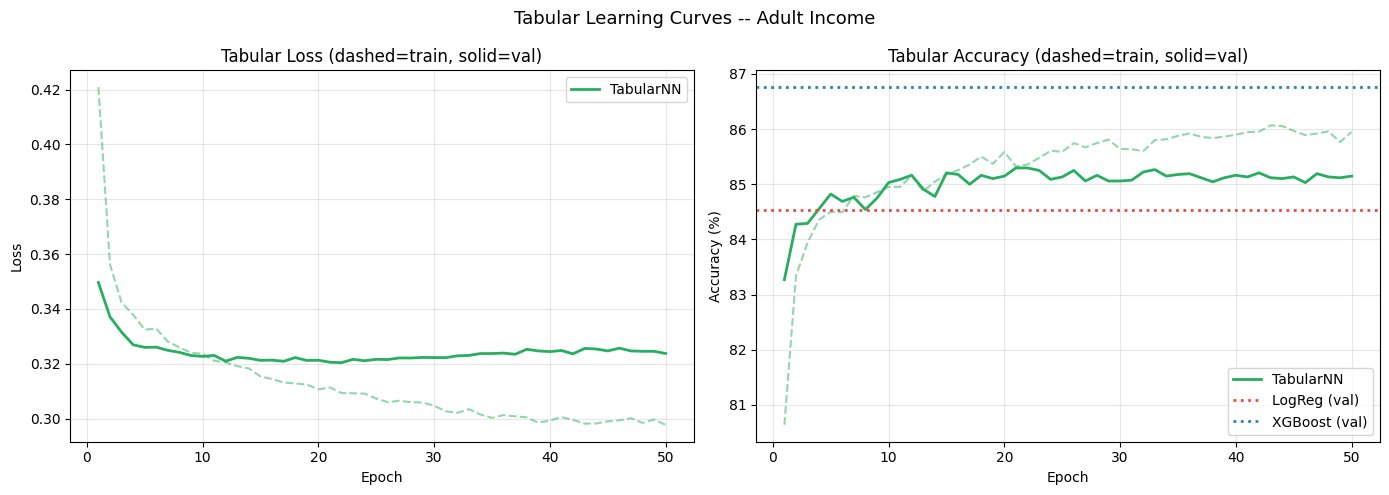

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tab_colors = {"LogReg": "#e74c3c", "XGBoost": "#2980b9", "TabularNN": "#27ae60"}

h = tab_histories["TabularNN"]
er = range(1, len(h["train_loss"]) + 1)
axes[0].plot(er, h["train_loss"], "--", color=tab_colors["TabularNN"], alpha=0.5)
axes[0].plot(er, h["val_loss"], "-", color=tab_colors["TabularNN"], label="TabularNN", linewidth=2)
axes[1].plot(er, [a*100 for a in h["train_acc"]], "--", color=tab_colors["TabularNN"], alpha=0.5)
axes[1].plot(er, [a*100 for a in h["val_acc"]], "-", color=tab_colors["TabularNN"], label="TabularNN", linewidth=2)

axes[1].axhline(y=100*tab_histories["LogReg"]["best_val_acc"], color=tab_colors["LogReg"],
                linestyle=":", linewidth=2, label="LogReg (val)")
axes[1].axhline(y=100*tab_histories["XGBoost"]["best_val_acc"], color=tab_colors["XGBoost"],
                linestyle=":", linewidth=2, label="XGBoost (val)")

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Tabular Loss (dashed=train, solid=val)")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Tabular Accuracy (dashed=train, solid=val)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Tabular Learning Curves -- Adult Income", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/tabular_learning_curves.png", dpi=150)
plt.show()


## 5 — Test Set Evaluation


In [7]:
TAB_CLASS_NAMES = ["<=50K", ">50K"]
tab_test_results = {}

for name, model, is_sk in [("LogReg", tab_lr, True), ("XGBoost", tab_xgb, True), ("TabularNN", tab_nn, False)]:
    if is_sk:
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)
    else:
        model.eval()
        X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        with torch.no_grad():
            logits = model(X_t)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average="macro")
    auroc = roc_auc_score(y_test, probs[:, 1])
    tab_test_results[name] = {"accuracy": acc, "precision_macro": prec, "recall_macro": rec,
        "f1_macro": f1, "auroc_macro": auroc, "labels": y_test, "preds": preds, "probs": probs}

    print(f"{name} -- Acc: {100*acc:.2f}% | F1: {100*f1:.2f}% | AUROC: {auroc:.4f}")
    print(classification_report(y_test, preds, target_names=TAB_CLASS_NAMES, digits=3))


LogReg -- Acc: 84.77% | F1: 78.07% | AUROC: 0.9048
              precision    recall  f1-score   support

       <=50K      0.875     0.931     0.902      5103
        >50K      0.740     0.595     0.659      1681

    accuracy                          0.848      6784
   macro avg      0.807     0.763     0.781      6784
weighted avg      0.841     0.848     0.842      6784

XGBoost -- Acc: 86.53% | F1: 80.64% | AUROC: 0.9252
              precision    recall  f1-score   support

       <=50K      0.886     0.942     0.913      5103
        >50K      0.781     0.634     0.700      1681

    accuracy                          0.865      6784
   macro avg      0.834     0.788     0.806      6784
weighted avg      0.860     0.865     0.860      6784

TabularNN -- Acc: 84.73% | F1: 78.02% | AUROC: 0.9078
              precision    recall  f1-score   support

       <=50K      0.875     0.930     0.902      5103
        >50K      0.738     0.595     0.659      1681

    accuracy             

## 6 — Confusion Matrices


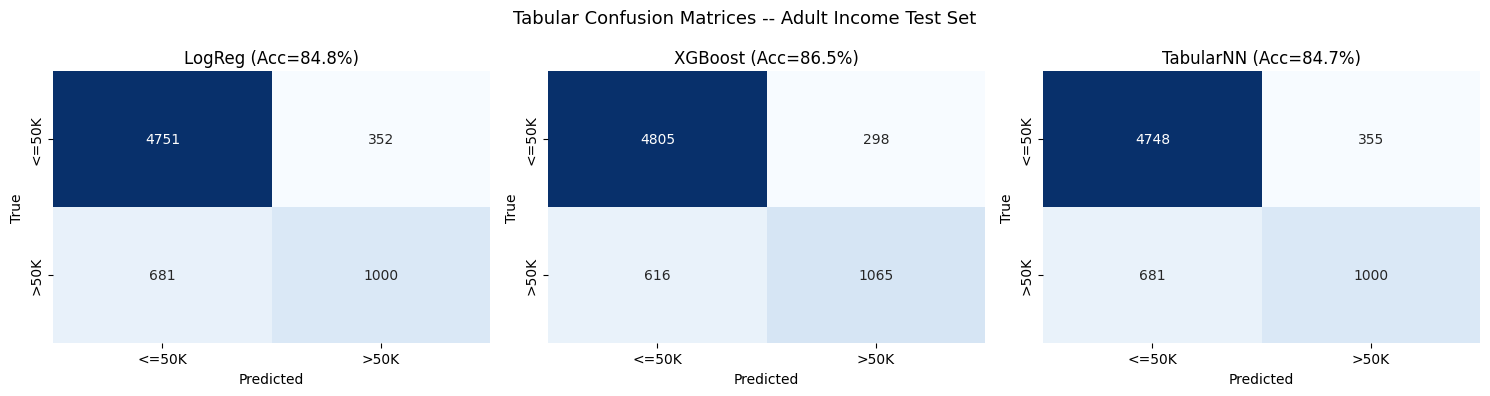

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, res) in enumerate(tab_test_results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=TAB_CLASS_NAMES,
                yticklabels=TAB_CLASS_NAMES, ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name} (Acc={100*res['accuracy']:.1f}%)")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")
plt.suptitle("Tabular Confusion Matrices -- Adult Income Test Set", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/tabular_confusion_matrices.png", dpi=150)
plt.show()


## 7 — Adversarial Attacks

Feature-space perturbations with realistic constraints:
- **Gaussian Noise (sigma=0.1, 0.3)**: Additive noise clamped to training-set feature ranges

200 test samples per model per attack.


In [9]:
TAB_ATK_N = 200
sample_idx = random.sample(range(len(X_test)), TAB_ATK_N)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]

def noise_attack(X, sigma=0.1):
    noise = np.random.normal(0, sigma, X.shape)
    X_adv = X + noise
    return np.clip(X_adv, X_train_min, X_train_max)

tab_atk_configs = {
    "Noise_0.1": lambda X: noise_attack(X, sigma=0.1),
    "Noise_0.3": lambda X: noise_attack(X, sigma=0.3),
}

tab_adv_results = {}

for name, model, is_sk in [("LogReg", tab_lr, True), ("XGBoost", tab_xgb, True), ("TabularNN", tab_nn, False)]:
    tab_adv_results[name] = {}
    print()
    print("=" * 60)
    print(f"Attacking: {name}")
    print("=" * 60)

    if is_sk:
        clean_probs = model.predict_proba(X_sample)
    else:
        model.eval()
        with torch.no_grad():
            clean_probs = F.softmax(
                model(torch.tensor(X_sample, dtype=torch.float32).to(device)), dim=1
            ).cpu().numpy()

    clean_preds = clean_probs.argmax(axis=1)
    clean_confs = clean_probs.max(axis=1)
    clean_acc = (clean_preds == y_sample).mean()

    for atk_name, atk_fn in tab_atk_configs.items():
        t0 = time.time()
        X_adv = atk_fn(X_sample)

        if is_sk:
            adv_probs = model.predict_proba(X_adv)
        else:
            with torch.no_grad():
                adv_probs = F.softmax(
                    model(torch.tensor(X_adv, dtype=torch.float32).to(device)), dim=1
                ).cpu().numpy()

        adv_preds = adv_probs.argmax(axis=1)
        adv_confs = adv_probs.max(axis=1)
        adv_acc = (adv_preds == y_sample).mean()
        asr = (clean_preds != adv_preds).mean()
        conf_drop = float(clean_confs.mean() - adv_confs.mean())

        class_asr = []
        for c in range(2):
            mask = y_sample == c
            if mask.sum() > 0:
                class_asr.append(((clean_preds != adv_preds) & mask).sum() / mask.sum())
            else:
                class_asr.append(0.0)
        worst_class_asr = max(class_asr)
        accuracy_drop = clean_acc - adv_acc
        risk_score, gate = compute_risk_score(accuracy_drop, conf_drop, asr, worst_class_asr)
        elapsed = time.time() - t0

        tab_adv_results[name][atk_name] = {
            "clean_acc": clean_acc, "adv_acc": adv_acc, "accuracy_drop": accuracy_drop,
            "asr": asr, "confidence_drop": conf_drop, "worst_class_asr": worst_class_asr,
            "risk_score": risk_score, "gate": gate, "attack_time_s": elapsed}
        print(f"  {atk_name}: Adv Acc={100*adv_acc:.1f}% | ASR={100*asr:.1f}% | "
              f"ConfDrop={conf_drop:.3f} | WorstClassASR={100*worst_class_asr:.1f}% | "
              f"Risk={risk_score:.4f} [{gate}] | {elapsed:.1f}s")



Attacking: LogReg
  Noise_0.1: Adv Acc=80.0% | ASR=1.5% | ConfDrop=0.004 | WorstClassASR=3.3% | Risk=0.0115 [PASS] | 0.0s
  Noise_0.3: Adv Acc=80.5% | ASR=4.0% | ConfDrop=-0.003 | WorstClassASR=11.5% | Risk=0.0272 [PASS] | 0.0s

Attacking: XGBoost
  Noise_0.1: Adv Acc=74.0% | ASR=14.5% | ConfDrop=-0.072 | WorstClassASR=32.8% | Risk=0.1117 [PASS] | 0.0s
  Noise_0.3: Adv Acc=72.5% | ASR=17.0% | ConfDrop=-0.069 | WorstClassASR=34.4% | Risk=0.1256 [PASS] | 0.0s

Attacking: TabularNN
  Noise_0.1: Adv Acc=82.5% | ASR=1.5% | ConfDrop=-0.003 | WorstClassASR=3.3% | Risk=0.0034 [PASS] | 0.0s
  Noise_0.3: Adv Acc=78.5% | ASR=5.5% | ConfDrop=-0.012 | WorstClassASR=6.6% | Risk=0.0323 [PASS] | 0.0s


## 8 — Adversarial Accuracy Comparison Plot


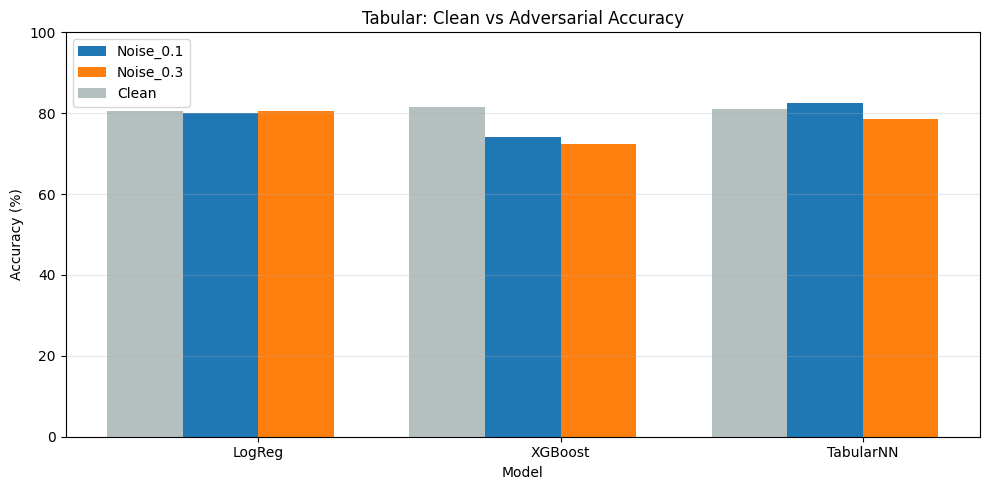

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.25
models = list(tab_adv_results.keys())
attacks = list(tab_atk_configs.keys())
x = np.arange(len(models))

for i, atk in enumerate(attacks):
    vals = [100 * tab_adv_results[m][atk]["adv_acc"] for m in models]
    ax.bar(x + i * bar_width, vals, bar_width, label=atk)

# Add clean accuracy bars
clean_vals = [100 * tab_adv_results[m][attacks[0]]["clean_acc"] for m in models]
ax.bar(x - bar_width, clean_vals, bar_width, label="Clean", color="#95a5a6", alpha=0.7)

ax.set_xlabel("Model")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Tabular: Clean vs Adversarial Accuracy")
ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(models)
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("outputs/plots/tabular_adversarial_comparison.png", dpi=150)
plt.show()


## 9 — Risk Score Heatmap


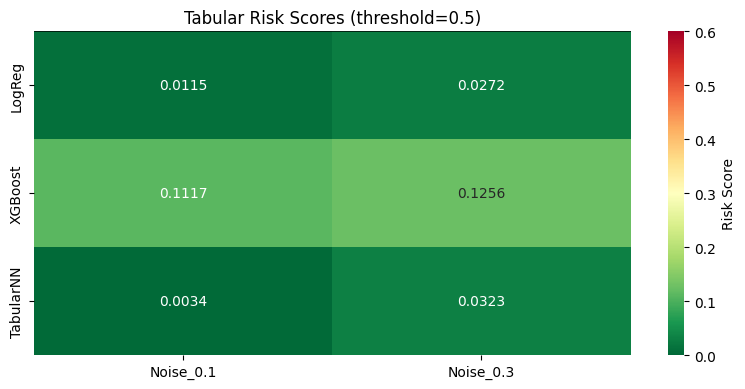

In [11]:
models_list = list(tab_adv_results.keys())
attacks_list = list(list(tab_adv_results.values())[0].keys())
risk_matrix = np.array([[tab_adv_results[m][a]["risk_score"] for a in attacks_list] for m in models_list])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(risk_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r",
            xticklabels=attacks_list, yticklabels=models_list,
            vmin=0, vmax=0.6, ax=ax, cbar_kws={"label": "Risk Score"})
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_title("Tabular Risk Scores (threshold=0.5)")
plt.tight_layout()
plt.savefig("outputs/plots/tabular_risk_heatmap.png", dpi=150)
plt.show()


## 10 — Inference Benchmarks


In [12]:
tab_inf_results = {}

for name, model, is_sk in [("LogReg", tab_lr, True), ("XGBoost", tab_xgb, True), ("TabularNN", tab_nn, False)]:
    latencies = []
    for i in range(min(500, len(X_test))):
        sample = X_test[i:i+1]
        if is_sk:
            t0 = time.perf_counter()
            _ = model.predict_proba(sample)
            latencies.append((time.perf_counter() - t0) * 1000)
        else:
            model.eval()
            x_t = torch.tensor(sample, dtype=torch.float32).to(device)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            with torch.no_grad():
                _ = model(x_t)
            if device.type == "cuda":
                torch.cuda.synchronize()
            latencies.append((time.perf_counter() - t0) * 1000)

    if is_sk:
        ts = time.time()
        _ = model.predict_proba(X_test)
        tp = len(X_test) / (time.time() - ts)
        vram = 0
    else:
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
        X_all = torch.tensor(X_test, dtype=torch.float32).to(device)
        ts = time.time()
        with torch.no_grad():
            _ = model(X_all)
        if device.type == "cuda":
            torch.cuda.synchronize()
        tp = len(X_test) / (time.time() - ts)
        vram = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0

    tab_inf_results[name] = {
        "p50_ms": np.percentile(latencies, 50),
        "p90_ms": np.percentile(latencies, 90),
        "throughput_sps": tp,
        "inf_vram_mb": vram}
    print(f"{name}: p50={tab_inf_results[name]['p50_ms']:.2f}ms | "
          f"p90={tab_inf_results[name]['p90_ms']:.2f}ms | "
          f"throughput={tp:.0f} samp/s | VRAM={vram:.0f}MB")


LogReg: p50=0.28ms | p90=0.35ms | throughput=4249426 samp/s | VRAM=0MB
XGBoost: p50=0.68ms | p90=0.84ms | throughput=404201 samp/s | VRAM=0MB
TabularNN: p50=0.17ms | p90=0.21ms | throughput=526705 samp/s | VRAM=0MB


## 11 — Summary Table


In [13]:
rows = []
for name in ["LogReg", "XGBoost", "TabularNN"]:
    h = tab_histories[name]; t = tab_test_results[name]
    m = tab_model_meta[name]; inf = tab_inf_results[name]
    worst_atk = max(tab_adv_results[name].items(), key=lambda x: x[1]["risk_score"])
    p = m["params"]
    pstr = f"{p:,}" if isinstance(p, int) else str(p)
    rows.append({
        "Model": name, "Params": pstr,
        "Train Time": f"{h['total_time']:.0f}s",
        "Test Acc (%)": f"{100*t['accuracy']:.2f}",
        "F1 Macro (%)": f"{100*t['f1_macro']:.2f}",
        "AUROC": f"{t['auroc_macro']:.4f}",
        "Worst ASR (%)": f"{100*worst_atk[1]['asr']:.1f}",
        "Worst Risk": f"{worst_atk[1]['risk_score']:.4f}",
        "Gate": worst_atk[1]["gate"],
        "p50 (ms)": f"{inf['p50_ms']:.2f}",
        "Throughput": f"{inf['throughput_sps']:.0f}"})

summary_df = pd.DataFrame(rows)
summary_df.to_csv("outputs/tabular_cls_summary.csv", index=False)
print("=" * 80)
print("TABULAR CLASSIFICATION SUMMARY -- ROBUSTOPS MILESTONE 2")
print("=" * 80)
print(summary_df.to_string(index=False))


TABULAR CLASSIFICATION SUMMARY -- ROBUSTOPS MILESTONE 2
    Model    Params Train Time Test Acc (%) F1 Macro (%)  AUROC Worst ASR (%) Worst Risk Gate p50 (ms) Throughput
   LogReg        98         1s        84.77        78.07 0.9048           4.0     0.0272 PASS     0.28    4249426
  XGBoost 100 trees         3s        86.53        80.64 0.9252          17.0     0.1256 PASS     0.68     404201
TabularNN    23,394        53s        84.73        78.02 0.9078           5.5     0.0323 PASS     0.17     526705
